In [1]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


#final_speed = 20.
num_cores = 200
maxtime = 1435
#runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
runID = "Fasymp2_fixgaussian20_50GW" # _nG30"

student = "Grating_Half"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
filepath = "combine_extract.ipynb"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 731622
Average function evaluations per core: 3658


In [2]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [3]:
import numpy as np
from scipy.optimize import minimize
from parameters import D1_ND

def get_final(l_min, l_max):
    doppler = l_min / l_max

    def test(v):
        v = v/100
        return np.abs(doppler - D1_ND(v))

    sol = minimize(test, 5)
    final_speed = sol.x[0]
    return final_speed

In [4]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 3

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

[1, np.float64(1.049999999971945)]
Total function evaluations: 731622
Average function evaluations per core: 3658
TORCWA
[tensor(1.6414, dtype=torch.float64), tensor(0.3615, dtype=torch.float64), tensor(0.3289, dtype=torch.float64), tensor(0.0489, dtype=torch.float64), tensor(0.7133, dtype=torch.float64), tensor(5.9662, dtype=torch.float64), tensor(10.3189, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.4050, dtype=torch.float64), tensor(4.5449, dtype=torch.float64)]
[tensor(1.6414, dtype=torch.float64), tensor(0.3615, dtype=torch.float64), tensor(0.3289, dtype=torch.float64), tensor(0.0489, dtype=torch.float64), tensor(0.7133, dtype=torch.float64), tensor(5.9662, dtype=torch.float64), tensor(10.3189, dtype=torch.float64), tensor(0.4050, dtype=torch.float64), tensor(4.5449, dtype=torch.float64)]
-53.704972639541005
grating_pitch   = 1.6414291336460194
grating_depth   = 0.36145882756673453
box1_width      = 0.3288692537983645
box2_width      = 0.048880858467287236
box_

In [5]:
scaled = np.sqrt(1.05) # Scale to new wavelength
scaled_opt_params = opt_params.copy()

param_ls = [0, 1, 2, 3, 4, 7, 8]
for p in param_ls:
    scaled_opt_params[p] = scaled * scaled_opt_params[p]
    
scaled_grating = TwoBox(*scaled_opt_params, wavelength=1., angle=0., 
                        Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf,
                        RCWA_engine=opt_grating.RCWA_engine, 
                        torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

final_speed = get_final(1., 1.05)

actual_fom = fom.multifom(scaled_grating, monofom=fom.monofom_asymp,
                            final_speed=final_speed, goal=0.1, return_grad=False)

print_grating_params(scaled_grating)
print(f"\nFoM at scaled wavelength: {actual_fom}")

grating_pitch   = 1.6819643518282479
grating_depth   = 0.3703850809997809
box1_width      = 0.3369907052109713
box2_width      = 0.05008797501121317
box_centre_dist = 0.7309133827665762
box1_eps        = 5.9661818180481125
box2_eps        = 10.318871293007803
gaussian_width  = 20.4939015319192
substrate_depth = 0.41499461247361696
substrate_eps   = 4.544925669174284

FoM at scaled wavelength: 0.00011613440695787647


In [6]:
stiffnesses = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

In [7]:
stiffnesses = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

In [8]:
eigvals = grating.npa.eigvals((J_scaled + J_original)/2)
eigReal = grating.npa.real(eigvals)
eigImag = grating.npa.imag(eigvals)
eigvals

tensor([-0.0004+165.8330j, -0.0004-165.8330j, -0.0002+29.1797j,
        -0.0002-29.1797j], dtype=torch.complex128,
       grad_fn=<LinalgEigBackward0>)

In [6]:
num_plot_points = 200

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating.wavelength = grating.npa.array(lam)
    scaled_grating.wavelength = scaled_grating.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J_original = grating.npa.concatenate((grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    stiffnesses = fom.force_coeff(scaled_grating,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J_scaled = scaled_grating.npa.concatenate((scaled_grating.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals((J_scaled + J_original)/2)
    
grating.wavelength = init_wavelength
scaled_grating.wavelength = init_wavelength
eigvals

tensor([[-2.4578e-04+229.9847j, -2.5152e-04+229.9702j, -2.5726e-04+229.9506j,
         -2.6299e-04+229.9260j, -2.6871e-04+229.8962j, -2.7443e-04+229.8610j,
         -2.8013e-04+229.8204j, -2.8582e-04+229.7742j, -2.9149e-04+229.7224j,
         -2.9715e-04+229.6649j, -3.0278e-04+229.6014j, -3.0840e-04+229.5320j,
         -3.1399e-04+229.4565j, -3.1956e-04+229.3747j, -3.2510e-04+229.2866j,
         -3.3060e-04+229.1921j, -3.3608e-04+229.0909j, -3.4152e-04+228.9831j,
         -3.4692e-04+228.8684j, -3.5228e-04+228.7468j, -3.5760e-04+228.6181j,
         -3.6287e-04+228.4823j, -3.6810e-04+228.3391j, -3.7327e-04+228.1885j,
         -3.7839e-04+228.0302j, -3.8346e-04+227.8643j, -3.8846e-04+227.6906j,
         -3.9341e-04+227.5089j, -3.9829e-04+227.3191j, -4.0310e-04+227.1211j,
         -4.0784e-04+226.9148j, -4.1251e-04+226.7000j, -4.1711e-04+226.4765j,
         -4.2162e-04+226.2444j, -4.2606e-04+226.0033j, -4.3041e-04+225.7532j,
         -4.3467e-04+225.4940j, -4.3884e-04+225.2255j, -4.4292e-

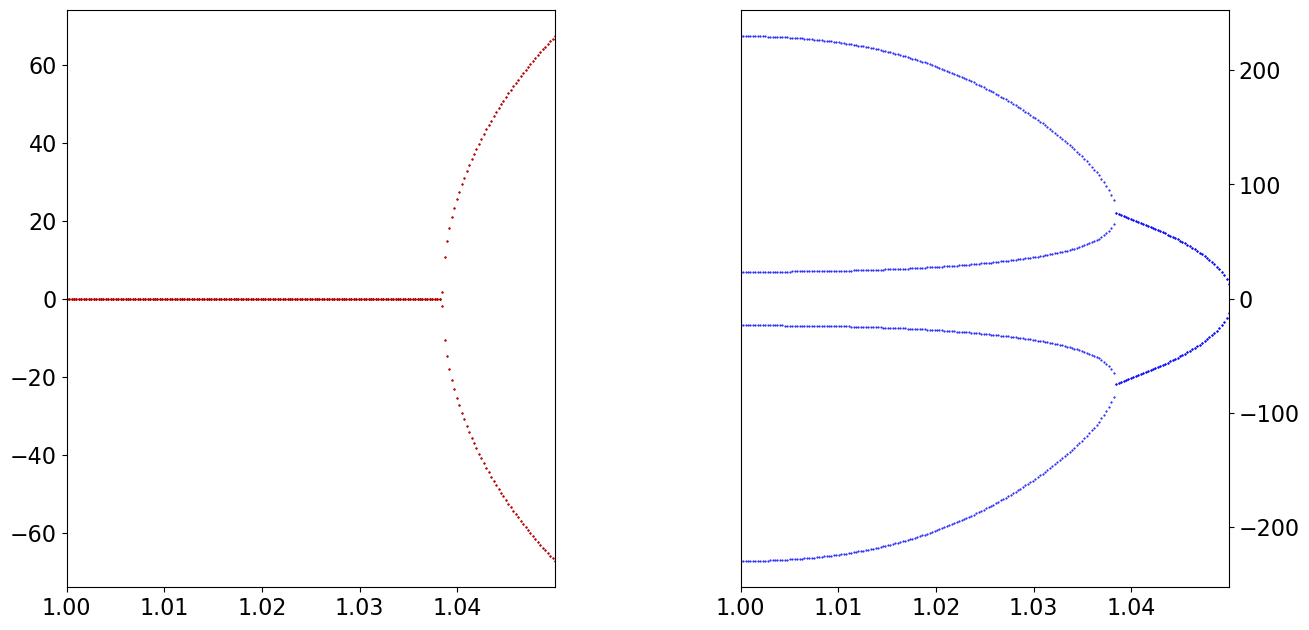

In [7]:
import matplotlib.pyplot as plt

fig, (ax1, dummy, ax2) = plt.subplots(nrows=1, ncols=3, width_ratios=(1,0.1,1))
dummy.axis('off')
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)
    ax2.plot(wavelengths,np.imag(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorImag, fillstyle='full',  color=colorImag)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

(-0.004, 0.001)

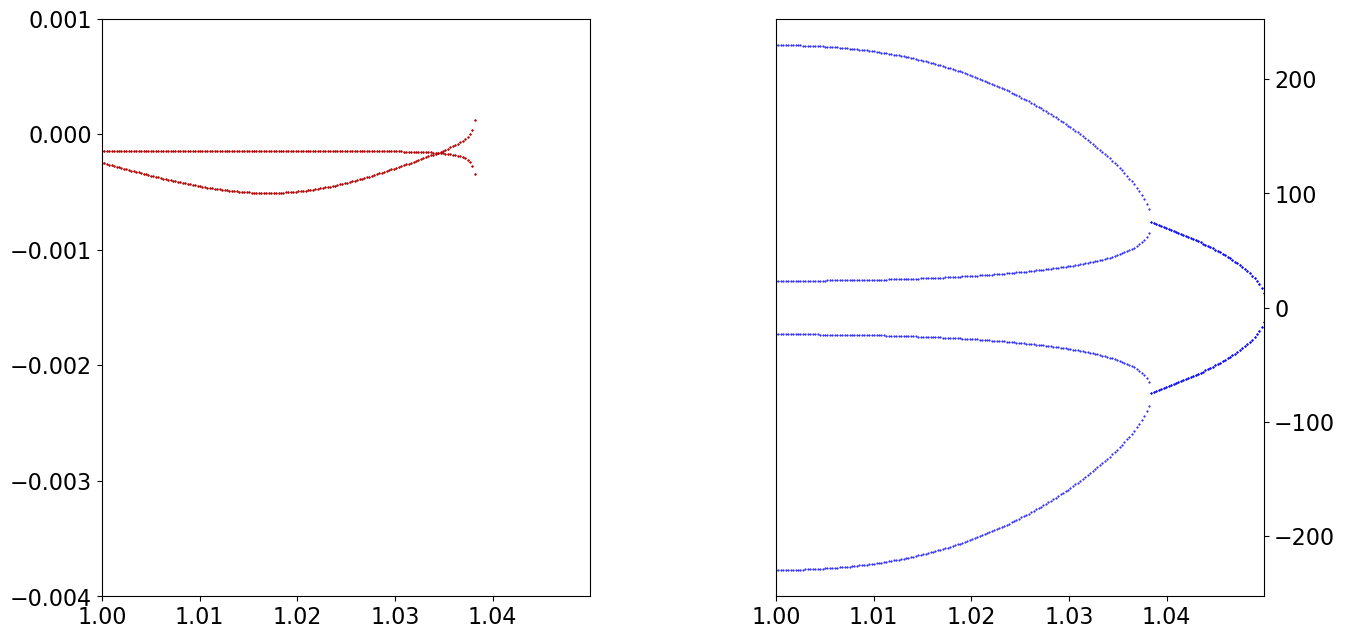

In [9]:
import matplotlib.pyplot as plt

fig, (ax1, dummy, ax2) = plt.subplots(nrows=1, ncols=3, width_ratios=(1,0.1,1))
dummy.axis('off')
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)
    ax2.plot(wavelengths,np.imag(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorImag, fillstyle='full',  color=colorImag)

#ax1.set_xlim((1, 1.4))
#ax2.set_xlim((1, 1.4))
ax1.set_ylim((-0.004, 0.001))

In [12]:
eigReal = grating.npa.real(eigvals)
fom_combined =  grating.npa.min(-eigReal)

print('FoM of combined (scaled), opt',i,' =',fom_combined.detach().numpy())

FoM of combined (scaled), opt 3  = -67.30569101415713
